In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
original_df = pd.read_csv("fiverr_data.csv")
df = original_df.copy()


In [17]:
df[df['label'] == 1].sample(1).T

,287051
label,1.0
user_id,302024.0
X1,11574.0
X2,147.0
X3,37.0
X4,1.0
X5,2.0
X6,4.0
X7,1.0
X8,21.0


In [4]:
df.sample(10)

,label,user_id,X1,X2,X3,X4,X5,X6,X7,X8,...,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51
399411,0,420410,14466,95,13,3,11,4,8,15,...,0,0,0,0,0,0,0,0,1,0
453600,0,477457,17587,19,13,3,16,4,4,22,...,0,0,0,1,0,0,0,0,1,0
173227,0,182038,17522,137,13,3,16,3,8,15,...,0,0,1,0,0,0,0,1,1,0
243894,0,256428,22542,213,36,1,9,2,1,22,...,0,0,0,0,0,0,0,0,0,0
162219,0,170501,11875,72,13,3,16,3,8,15,...,0,0,0,0,0,0,0,0,0,0
26470,0,27831,22066,142,13,3,11,3,2,15,...,0,0,1,0,0,0,0,0,1,0
14953,0,15723,14295,31,36,1,9,1,5,9,...,0,0,0,0,0,0,0,0,0,0
432415,0,455083,9949,205,13,3,11,4,3,15,...,0,0,1,0,0,0,0,0,1,0
114753,0,120649,21726,40,13,3,16,3,5,9,...,0,0,0,0,0,0,0,0,1,0
94048,0,98882,1,213,36,1,9,3,5,9,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(458798, 53)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 458798 entries, 0 to 458797
Data columns (total 53 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   label    458798 non-null  int64  
 1   user_id  458798 non-null  int64  
 2   X1       458798 non-null  int64  
 3   X2       458798 non-null  int64  
 4   X3       458798 non-null  int64  
 5   X4       458798 non-null  int64  
 6   X5       458798 non-null  int64  
 7   X6       458798 non-null  int64  
 8   X7       458798 non-null  int64  
 9   X8       458798 non-null  int64  
 10  X9       458798 non-null  int64  
 11  X10      458798 non-null  int64  
 12  X11      458798 non-null  int64  
 13  X12      458798 non-null  int64  
 14  X13      458792 non-null  float64
 15  X14      458798 non-null  int64  
 16  X15      458798 non-null  int64  
 17  X16      458798 non-null  int64  
 18  X17      458798 non-null  int64  
 19  X18      458798 non-null  int64  
 20  X19      458798 non-null  int64  
 21

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
label,458798.0,0.026855,0.161660,0.0,0.00,0.0,0.00,1.0
user_id,458798.0,241363.771411,139440.017203,1.0,120595.25,241234.5,362157.75,482935.0
X1,458798.0,10850.591243,7078.656632,1.0,4692.00,11574.0,16425.00,24234.0
X2,458798.0,154.947696,67.952267,1.0,95.00,189.0,213.00,222.0
X3,458798.0,28.107965,19.227303,1.0,13.00,14.0,37.00,94.0
X4,458798.0,2.407831,0.800163,1.0,2.00,3.0,3.00,3.0
X5,458798.0,10.985176,5.527487,1.0,8.00,11.0,16.00,17.0
X6,458798.0,3.215446,0.811902,1.0,3.00,3.0,4.00,4.0
X7,458798.0,5.082675,3.302548,1.0,2.00,5.0,8.00,11.0
X8,458798.0,15.654039,4.993260,1.0,14.00,15.0,21.00,29.0


In [8]:
df['user_id'].duplicated().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum().sum()

np.int64(6)

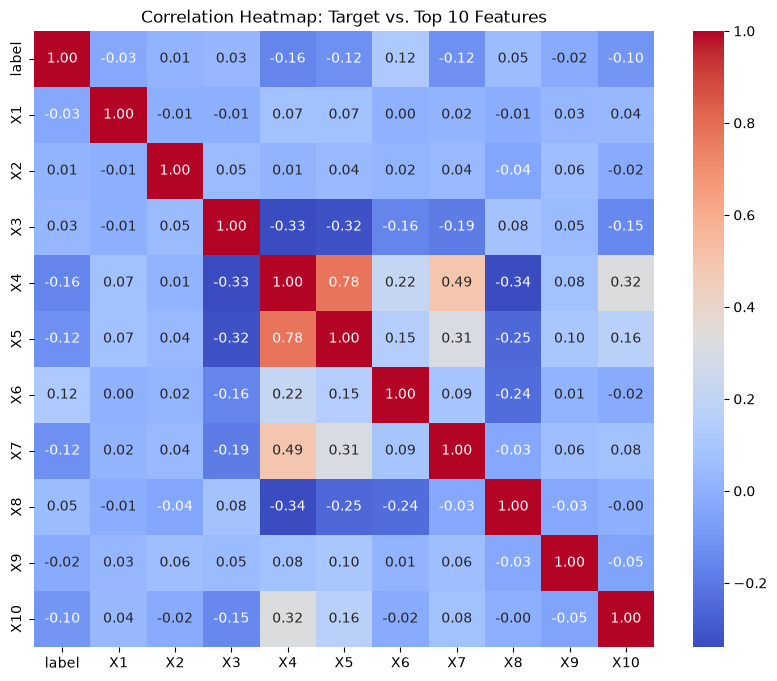

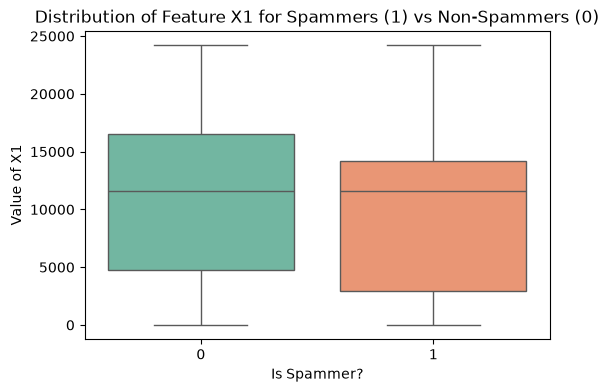

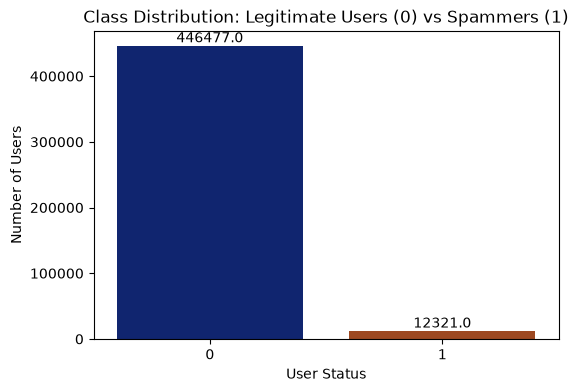

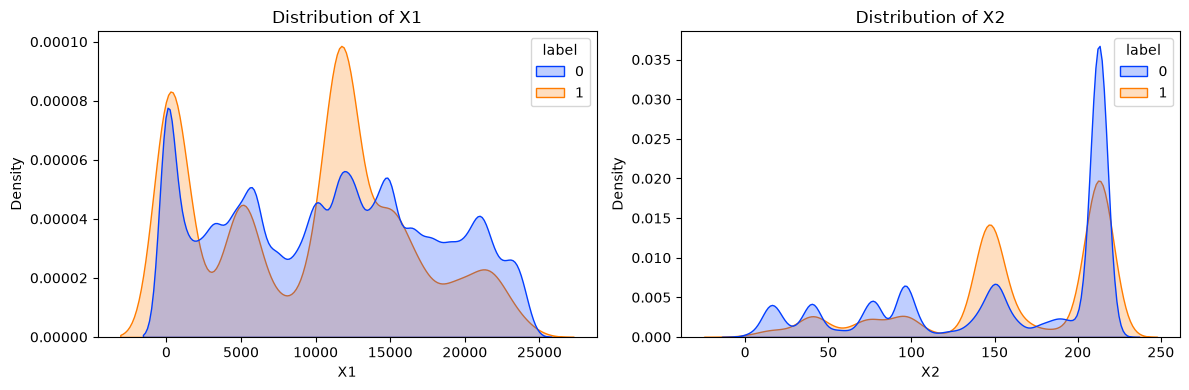

In [11]:

# Assuming 'df' is already loaded from previous steps
# 1. Correlation Heatmap (Checking the first 10 features + label)
cols_to_check = ['label', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
corr_matrix = df[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap: Target vs. Top 10 Features")
plt.show()

# 2. Boxplot to check for outliers in a specific feature across classes (e.g., X1)
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='X1', data=df, palette='Set2')
plt.title("Distribution of Feature X1 for Spammers (1) vs Non-Spammers (0)")
plt.xlabel("Is Spammer?")
plt.ylabel("Value of X1")
plt.show()

# 1. Target Imbalance Bar Chart
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette='dark')
plt.title("Class Distribution: Legitimate Users (0) vs Spammers (1)")
plt.ylabel("Number of Users")
plt.xlabel("User Status")

# Add the exact counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.show()

# 2. KDE Plot for a specific feature (Comparing distributions)
# Let's look at X1 and X2 to see if spammers behave differently
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=df, x='X1', hue='label', common_norm=False, fill=True, palette='bright', ax=axes[0])
axes[0].set_title('Distribution of X1')

sns.kdeplot(data=df, x='X2', hue='label', common_norm=False, fill=True, palette='bright', ax=axes[1])
axes[1].set_title('Distribution of X2')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# 1. Separate features and target
# We drop 'user_id' because an ID does not predict spam behavior and adds noise
X = df.drop(columns=['label', 'user_id']) 
y = df['label']

# 2. Stratified Train-Test Split 
# 'stratify=y' ensures both train and test sets keep the 97.3% / 2.7% ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Build the Preprocessing Pipeline
# RobustScaler is chosen because it handles potential extreme outliers better than StandardScaler
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 4. Fit the pipeline on the training data ONLY, then transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training data shape: {X_train_processed.shape}")
print(f"Testing data shape: {X_test_processed.shape}")

Training data shape: (367038, 51)
Testing data shape: (91760, 51)


--- Baseline Model: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.93     89296
           1       0.15      0.84      0.25      2464

    accuracy                           0.86     91760
   macro avg       0.57      0.85      0.59     91760
weighted avg       0.97      0.86      0.91     91760

ROC-AUC Score: 0.9249


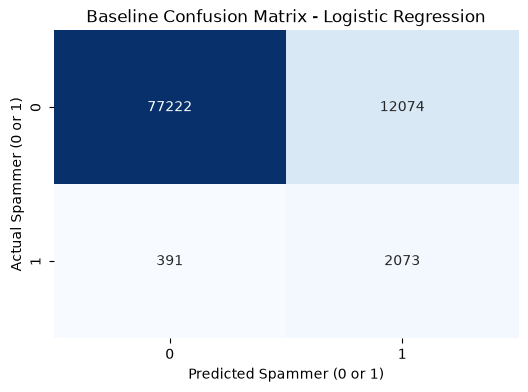

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the model
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
baseline_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# 2. Train the model on our preprocessed training data
baseline_model.fit(X_train_processed, y_train)

# 3. Make predictions on the test set
y_pred = baseline_model.predict(X_test_processed)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_processed)[:, 1]

# 4. Evaluate the performance
print("--- Baseline Model: Logistic Regression ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_baseline):.4f}")

# 5. Generate the Confusion Matrix (Save this plot for the MDD)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Baseline Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Spammer (0 or 1)')
plt.xlabel('Predicted Spammer (0 or 1)')
plt.show()

--- XGBoost Model Results ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     89296
           1       0.28      0.88      0.42      2464

    accuracy                           0.93     91760
   macro avg       0.64      0.91      0.69     91760
weighted avg       0.98      0.93      0.95     91760

ROC-AUC Score: 0.9660
   Feature  Importance
19     X20    0.258862
18     X19    0.211320
24     X25    0.073454
5       X6    0.072848
48     X49    0.038529
6       X7    0.036017
3       X4    0.033210
10     X11    0.028150
35     X36    0.021868
4       X5    0.017930
21     X22    0.016124
7       X8    0.013220
1       X2    0.011664
8       X9    0.010291
12     X13    0.009656
16     X17    0.009356
2       X3    0.008710
9      X10    0.008565
30     X31    0.008064
34     X35    0.007712


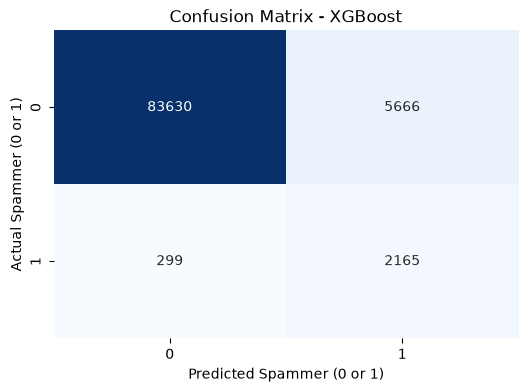

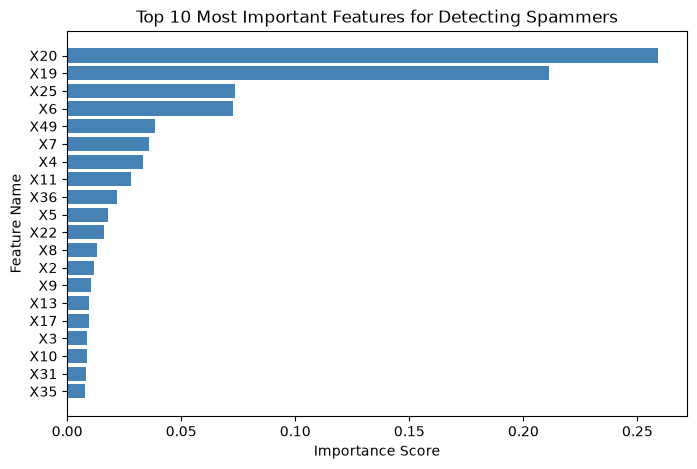

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd



# 3. Simple, step-by-step preprocessing (Imputing then Scaling)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = RobustScaler()
X_train_final = scaler.fit_transform(X_train_imputed)
X_test_final = scaler.transform(X_test_imputed)

# 4. Calculate class weight for the imbalance
weight = (y_train == 0).sum() / (y_train == 1).sum()

# 5. Train a clean, standard XGBoost model
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=weight, 
    random_state=42, 
    max_depth=5,           # Kept at 5 to prevent the model from becoming too complex
    n_estimators=100       # Standard number of trees
)
xgb_model.fit(X_train_final, y_train)

# 6. Make predictions
y_pred = xgb_model.predict(X_test_final)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

# 7. Print the results for the MDD
print("--- XGBoost Model Results ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

# 8. Plot Feature Importance (Crucial for the report)
importances = xgb_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)
print(importance_df)

# 5. Generate the Confusion Matrix (Save this plot for the MDD)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual Spammer (0 or 1)')
plt.xlabel('Predicted Spammer (0 or 1)')
plt.show()

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='steelblue')
plt.title('Top 10 Most Important Features for Detecting Spammers')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

--- Challenger Model: LightGBM ---
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     89296
           1       0.23      0.88      0.36      2464

    accuracy                           0.92     91760
   macro avg       0.61      0.90      0.66     91760
weighted avg       0.98      0.92      0.94     91760

ROC-AUC Score: 0.9616


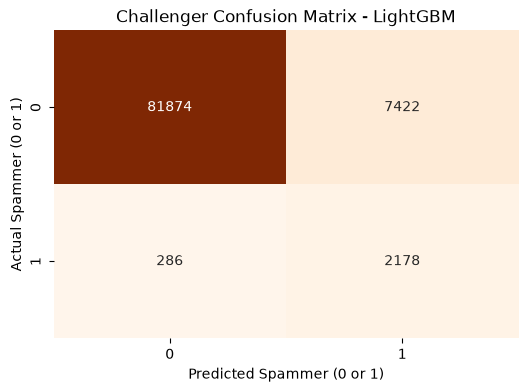

In [15]:
import lightgbm as lgb

# 1. Initialize the LightGBM model
# We use the same 'weight' variable calculated during the XGBoost step
# scale_pos_weight explicitly handles the 97% vs 3% class imbalance
lgb_model = lgb.LGBMClassifier(
    scale_pos_weight=weight, 
    random_state=42,
    max_depth=5,
    n_estimators=100,
    learning_rate=0.1,
    verbose=-1  # Suppresses unnecessary LightGBM terminal warnings
)

# 2. Train the challenger model on the final preprocessed training data
lgb_model.fit(X_train_final, y_train)

# 3. Make predictions on the test set
y_pred_lgb = lgb_model.predict(X_test_final)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_final)[:, 1]

# 4. Print the text results for the Model Evaluation section
print("--- Challenger Model: LightGBM ---")
print(classification_report(y_test, y_pred_lgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

# 5. Generate the Confusion Matrix Plot
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(6, 4))
# Using the 'Oranges' color map to visually distinguish it from the XGBoost plot in the report
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Challenger Confusion Matrix - LightGBM')
plt.ylabel('Actual Spammer (0 or 1)')
plt.xlabel('Predicted Spammer (0 or 1)')
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import lightgbm as lgb
import time

# Ensure 'weight' is defined from previous pipeline steps: 
# weight = (y_train == 0).sum() / (y_train == 1).sum()

# ==========================================
# 1. XGBoost GridSearchCV
# ==========================================
print("Starting XGBoost Grid Search...")
start_time = time.time()

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=weight,
    random_state=42,
    eval_metric='auc'
)

# Focused grid to prevent memory/time overload
xgb_param_grid = {
    'max_depth': [4, 6],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='roc_auc', # Optimizing for area under the curve
    cv=3,              # 3-fold cross validation saves significant compute time
    verbose=1,
    n_jobs=-1          # Uses all available CPU cores
)

xgb_grid.fit(X_train_final, y_train)

print(f"XGBoost Grid Search Completed in {(time.time() - start_time):.2f} seconds.")
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Best XGBoost ROC-AUC: {xgb_grid.best_score_:.4f}\n")


# ==========================================
# 2. LightGBM GridSearchCV
# ==========================================
print("Starting LightGBM Grid Search...")
start_time = time.time()

lgb_base = lgb.LGBMClassifier(
    scale_pos_weight=weight,
    random_state=42,
    verbose=-1
)

# Matching the exact grid constraints for a fair bake-off
lgb_param_grid = {
    'max_depth': [4, 6],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

lgb_grid = GridSearchCV(
    estimator=lgb_base,
    param_grid=lgb_param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

lgb_grid.fit(X_train_final, y_train)

print(f"LightGBM Grid Search Completed in {(time.time() - start_time):.2f} seconds.")
print(f"Best LightGBM Parameters: {lgb_grid.best_params_}")
print(f"Best LightGBM ROC-AUC: {lgb_grid.best_score_:.4f}")

Starting XGBoost Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost Grid Search Completed in 52.91 seconds.
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best XGBoost ROC-AUC: 0.9625

Starting LightGBM Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
LightGBM Grid Search Completed in 62.54 seconds.
Best LightGBM Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best LightGBM ROC-AUC: 0.9620


In [17]:
# Extract the fully optimized models
best_xgb_model = xgb_grid.best_estimator_
best_lgb_model = lgb_grid.best_estimator_

# Generate the final predictions
y_pred_opt_xgb = best_xgb_model.predict(X_test_final)
y_pred_opt_lgb = best_lgb_model.predict(X_test_final)

# You can now pass these into confusion_matrix() just like before

--- Optimized Champion Model: XGBoost ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     89296
           1       0.29      0.88      0.44      2464

    accuracy                           0.94     91760
   macro avg       0.64      0.91      0.70     91760
weighted avg       0.98      0.94      0.95     91760

ROC-AUC Score: 0.9661



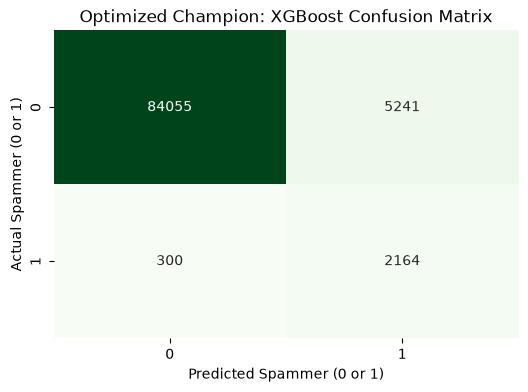

--- Optimized Challenger Model: LightGBM ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     89296
           1       0.27      0.88      0.41      2464

    accuracy                           0.93     91760
   macro avg       0.63      0.91      0.69     91760
weighted avg       0.98      0.93      0.95     91760

ROC-AUC Score: 0.9663



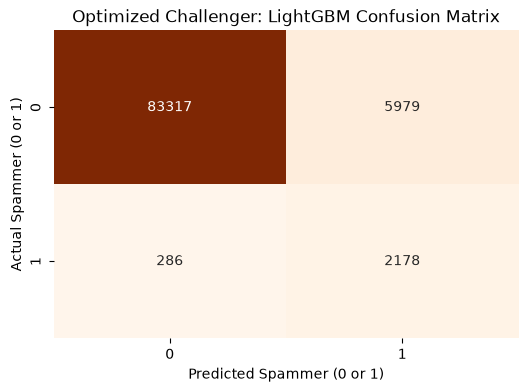

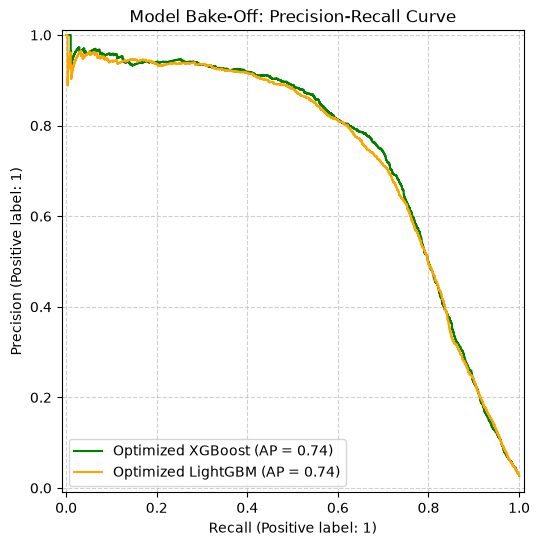

In [18]:
from sklearn.metrics import PrecisionRecallDisplay

# ==========================================
# 1. Evaluate Optimized XGBoost (Champion)
# ==========================================
# Get probabilities for ROC/PR curves
y_pred_proba_opt_xgb = best_xgb_model.predict_proba(X_test_final)[:, 1]

print("--- Optimized Champion Model: XGBoost ---")
print(classification_report(y_test, y_pred_opt_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_opt_xgb):.4f}\n")

# Plot XGBoost Confusion Matrix
cm_opt_xgb = confusion_matrix(y_test, y_pred_opt_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt_xgb, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Optimized Champion: XGBoost Confusion Matrix')
plt.ylabel('Actual Spammer (0 or 1)')
plt.xlabel('Predicted Spammer (0 or 1)')
plt.show()


# ==========================================
# 2. Evaluate Optimized LightGBM (Challenger)
# ==========================================
# Get probabilities for ROC/PR curves
y_pred_proba_opt_lgb = best_lgb_model.predict_proba(X_test_final)[:, 1]

print("--- Optimized Challenger Model: LightGBM ---")
print(classification_report(y_test, y_pred_opt_lgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_opt_lgb):.4f}\n")

# Plot LightGBM Confusion Matrix
cm_opt_lgb = confusion_matrix(y_test, y_pred_opt_lgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt_lgb, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Optimized Challenger: LightGBM Confusion Matrix')
plt.ylabel('Actual Spammer (0 or 1)')
plt.xlabel('Predicted Spammer (0 or 1)')
plt.show()


# ==========================================
# 3. Precision-Recall Curve (The Bake-Off Graph)
# ==========================================
plt.figure(figsize=(8, 6))

# Plot both models on the same axis for direct comparison
ax = plt.gca()
PrecisionRecallDisplay.from_estimator(
    best_xgb_model, X_test_final, y_test, 
    name="Optimized XGBoost", ax=ax, color='green'
)
PrecisionRecallDisplay.from_estimator(
    best_lgb_model, X_test_final, y_test, 
    name="Optimized LightGBM", ax=ax, color='orange'
)

plt.title('Model Bake-Off: Precision-Recall Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

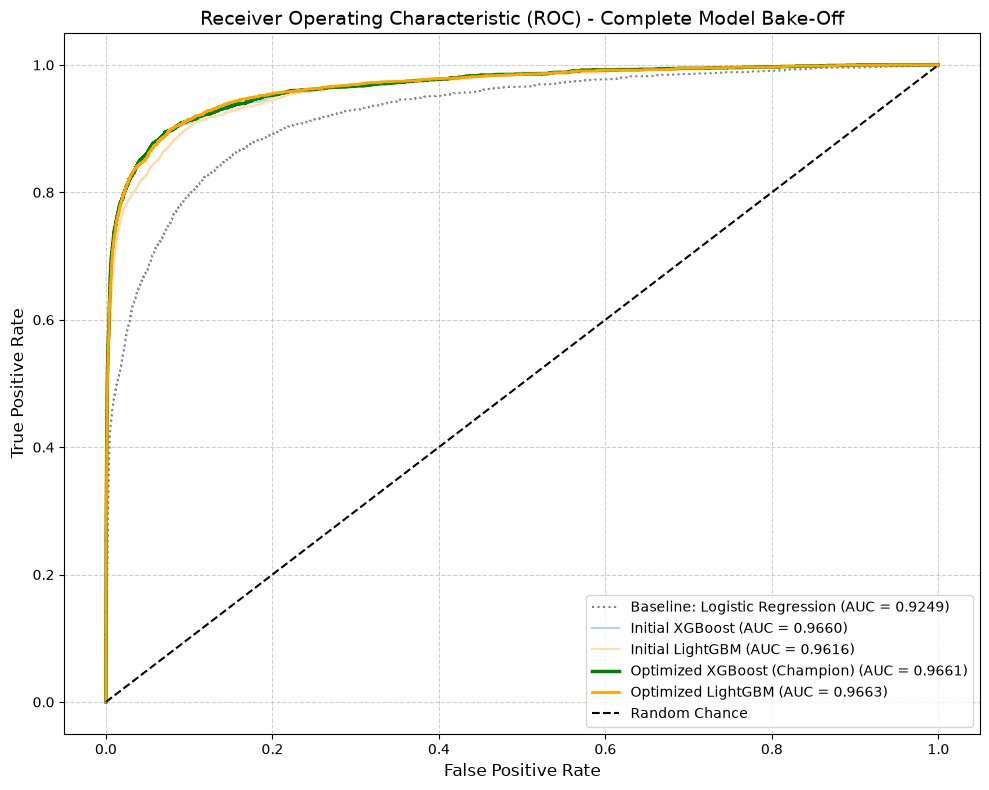

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

# Define a clean helper function to calculate and plot each curve
def plot_roc_curve(y_true, y_probs, name, color, linestyle='-', linewidth=1.5):
    # Calculate the False Positive Rate (FPR) and True Positive Rate (TPR)
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    # Calculate the exact AUC score to display in the legend
    auc_score = roc_auc_score(y_true, y_probs)
    
    # Plot directly using matplotlib
    plt.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=linewidth,
             label=f"{name} (AUC = {auc_score:.4f})")

# 1. The Baseline (Logistic Regression)
plot_roc_curve(y_test, y_pred_proba_baseline, "Baseline: Logistic Regression", color='gray', linestyle=':')

# 2. The Initial Champion (XGBoost)
plot_roc_curve(y_test, y_pred_proba_xgb, "Initial XGBoost", color='lightblue')

# 3. The Initial Challenger (LightGBM)
plot_roc_curve(y_test, y_pred_proba_lgb, "Initial LightGBM", color='navajowhite')

# 4. The Optimized Champion (XGBoost)
# Using a thicker line and strong green color to highlight the final selected model
plot_roc_curve(y_test, y_pred_proba_opt_xgb, "Optimized XGBoost (Champion)", color='green', linewidth=2.5)

# 5. The Optimized Challenger (LightGBM)
plot_roc_curve(y_test, y_pred_proba_opt_lgb, "Optimized LightGBM", color='orange', linewidth=2)

# Add the 'Random Chance' diagonal line for reference
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Chance')

# Final Formatting for the MDD
plt.title('Receiver Operating Characteristic (ROC) - Complete Model Bake-Off', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

In [19]:
import joblib
from sklearn.pipeline import Pipeline

# 1. Build the simple pipeline using the exact steps we tested
final_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('model', best_xgb_model)  # Your optimized XGBoost from the grid search
])

# 2. Fit the complete pipeline on the raw training data 
# Note: Use the X_train from BEFORE we manually scaled things in Phase 4
final_pipeline.fit(X_train, y_train)

# 3. Export the pipeline to a .pkl file for your Streamlit app
joblib.dump(final_pipeline, 'xgboost_champion_pipeline.pkl')

print("Pipeline successfully exported as 'xgboost_champion_pipeline.pkl'")

Pipeline successfully exported as 'xgboost_champion_pipeline.pkl'
